In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv1D, Flatten
from keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns


2024-08-12 11:14:21.566290: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-12 11:14:21.566433: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-12 11:14:21.759996: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# Load and preprocess the data
data_path = '/kaggle/input/insurance/insurance.csv'
data = pd.read_csv(data_path)

# Display the first few rows of the dataset to understand its structure
print("First few rows of the dataset:")
print(data.head())

# Check for missing values in the dataset
print("\nMissing values in each column:")
print(data.isnull().sum())

First few rows of the dataset:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Missing values in each column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [3]:
# Convert categorical variables to numeric
data['smoker'] = data['smoker'].map({'yes': 1, 'no': 0})
data['sex'] = data['sex'].map({'male': 1, 'female': 0})
data['region'] = data['region'].map({'northeast': 0, 'northwest': 1, 'southeast': 2, 'southwest': 3})

# Feature engineering: adding interaction and polynomial features
data['bmi_age_interaction'] = data['bmi'] * data['age']
data['age_squared'] = data['age'] ** 2

# Define feature columns and target variable
X = data.drop(columns=['charges'])
y = data['charges']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape the data for Conv1D layer (samples, timesteps, features)
X_train_scaled = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_scaled = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

**Building and Training the Model**


In [6]:
# Building the Convolutional Neural Network model
model = Sequential()
model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(X_train_scaled.shape[1], 1)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))

# Compile the model with Mean Squared Error loss and Adam optimizer
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 296942240.0000 - val_loss: 309582496.0000
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 336201984.0000 - val_loss: 299427680.0000
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 319748416.0000 - val_loss: 237826752.0000
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 244122528.0000 - val_loss: 119994504.0000
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 101568648.0000 - val_loss: 97339048.0000
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 89860016.0000 - val_loss: 83005832.0000
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 74980680.0000 - val_loss: 71948240.0000
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 70213888.0000 - val_loss: 62179476.0000
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 56674684.0000 - val_loss: 53991700.0000
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 49284840.0000 - val_loss: 47275620.0000

In [8]:
# Evaluate the model performance on the test set
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"\nTest MSE: {mse:.2f}")
print(f"Neural Network Model - R-squared: {r2:.4f}")
print(f"Neural Network Model - RMSE: {rmse:.2f}")
print(f"Neural Network Model - MAE: {mae:.2f}")
print(f"Neural Network Model - MAPE: {mape:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

Test MSE: 18966788.73
Neural Network Model - R-squared: 0.8778
Neural Network Model - RMSE: 4355.09
Neural Network Model - MAE: 2619.89
Neural Network Model - MAPE: 0.3310


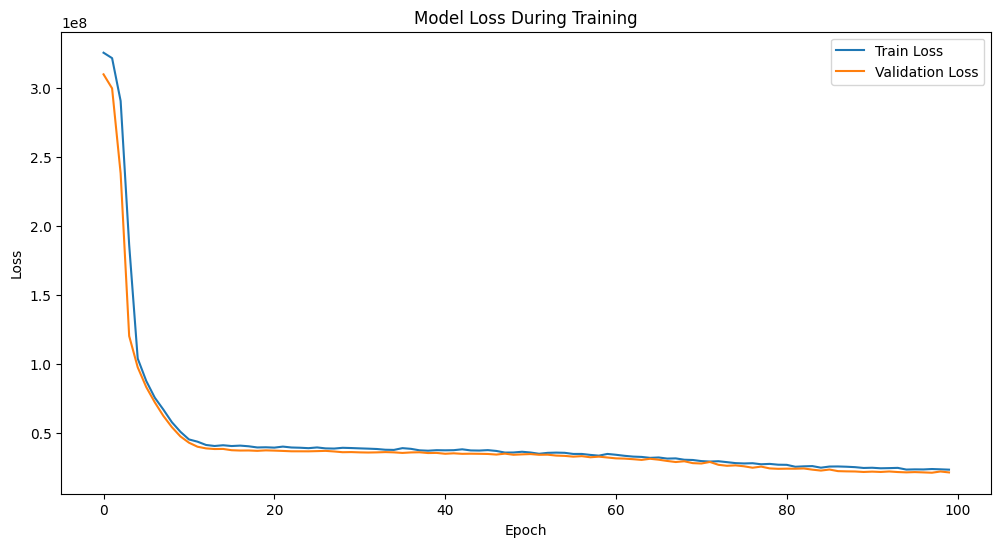

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


**Scatter Plot: Predictions vs. Actual Values**

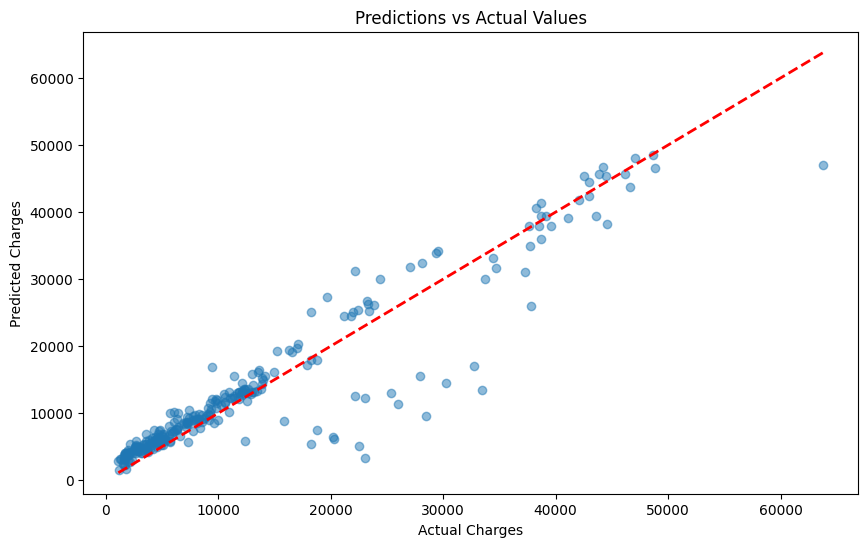

In [10]:
# Scatter plot of Predictions vs. Actual Values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Predictions vs Actual Values')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)
plt.show()

**Predicting Charges for New Data**

In [11]:
def preprocess_input_data(age, bmi, children, smoker, region, sex, feature_columns):
    features = {
        'age': age,
        'bmi': bmi,
        'children': children,
        'smoker': 1 if smoker == 'yes' else 0,
        'region': {'northeast': 0, 'northwest': 1, 'southeast': 2, 'southwest': 3}[region],
        'sex': 1 if sex == 'male' else 0,
        'bmi_age_interaction': bmi * age,
        'age_squared': age ** 2
    }
    # Convert features into DataFrame with appropriate columns
    data_point = pd.DataFrame([features], columns=feature_columns)
    # Scale the new data point
    data_point_scaled = scaler.transform(data_point)
    # Reshape for Conv1D input
    data_point_scaled = data_point_scaled.reshape((data_point_scaled.shape[0], data_point_scaled.shape[1], 1))
    return data_point_scaled

# Predicting healthcare charges for new data
feature_columns = X.columns

In [12]:

bob_charges = model.predict(preprocess_input_data(19, 27.9, 0, 'yes', 'northwest', 'male', feature_columns))[0][0]
lisa_charges = model.predict(preprocess_input_data(40, 50, 2, 'no', 'southeast', 'female', feature_columns))[0][0]
john_charges = model.predict(preprocess_input_data(30, 31.2, 0, 'no', 'northeast', 'male', feature_columns))[0][0]

print(f"\nHealth care charges for Bob: ${bob_charges:.2f}")
print(f"Health care charges for Lisa: ${lisa_charges:.2f}")
print(f"Health care charges for John: ${john_charges:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

Health care charges for Bob: $20039.86
Health care charges for Lisa: $10892.51
Health care charges for John: $5367.73
